# DAY 7

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics


# set style for plots
plt.style.use('seaborn_v0_8_white' if 'seaborn_v0_8_white' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100 # set the dpi
# seed 
np.random.seed(42)

# 1. Ragne (Spread form Minimum to Maximum)

Plain Python calculation: 12°C
Numpy (np.max - np.min): 12°C
Numpy (np.ptp): 12°C


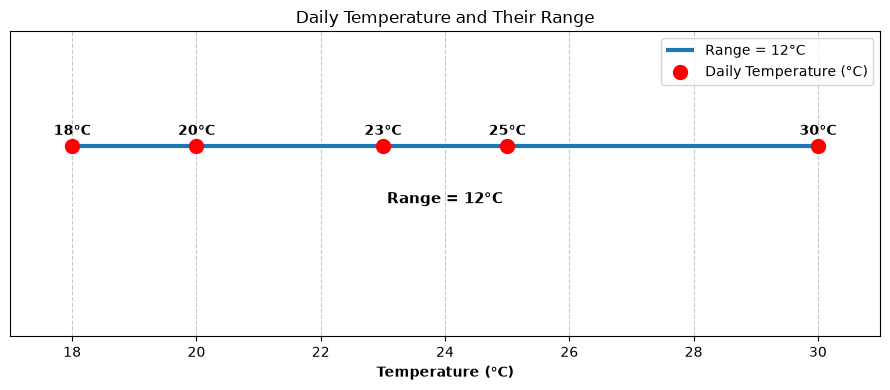

In [2]:
import numpy as np
import matplotlib.pyplot as plt

temperature = [18, 20, 23, 25, 30]

# Minimum and maximum values
min_val = min(temperature)
max_val = max(temperature)

# Range calculations
range_python = max(temperature) - min(temperature)

range_np_minmax = np.max(temperature) - np.min(temperature)

range_np_ptp = np.ptp(temperature)

print(f"Plain Python calculation: {range_python}°C")
print(f"Numpy (np.max - np.min): {range_np_minmax}°C")
print(f"Numpy (np.ptp): {range_np_ptp}°C")


# Graphical representation
plt.figure(figsize=(9, 4))

# Horizontal line from minimum to maximum
plt.hlines(
    y=1,
    xmin=min_val,
    xmax=max_val,
    linewidth=3,
    label=f"Range = {range_np_ptp}°C"
)
plt.text(
    (min_val + max_val) / 2,
    0.88,
    f"Range = {range_np_ptp}°C",
    ha='center',
    va='top',
    fontsize=11,
    fontweight='bold'
)
# Temperature points
plt.scatter(
    temperature,
    [1] * len(temperature),
    color='red',
    s=100,
    zorder=2,
    label='Daily Temperature (°C)'
)

# Temperature labels
for i, temp in enumerate(temperature):
    plt.text(
        temp,
        1.02,
        f"{temp}°C",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0.5, 1.3)
plt.xlim(min_val - 1, max_val + 1)

plt.yticks([])

plt.xlabel("Temperature (°C)", fontweight='bold')
plt.title("Daily Temperature and Their Range")

plt.grid(
    True,
    linestyle='--',
    alpha=0.7,
    axis='x'
)

plt.legend()
plt.tight_layout()
plt.show()

# 2. Interquartile Range (IQR - Middle 50% Spread)

In [3]:
import math


def get_percentile_linear(data, percentile):
    """Calculates percentile using linear interpolation (NumPy default equivalent)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Fractional index position
    index = (percentile / 100) * (n - 1)
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

def get_percentile_weibull(data, percentile):
    """Calculates percentile using the Weibull method (similar to Excel's PERCENTILE.INC)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Weibull formula for percentile rank
    rank = (percentile / 100) * (n + 1)
    index = rank - 1 # why -1 ? Because the formula calculates a 1-based index, but Python uses 0-based indexing.
    if index < 0:
        return sorted_data[0]
    elif index >= n - 1:
        return sorted_data[-1]
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

scores = [10, 50, 60, 70, 80, 85, 100]

# Example usage
q1_linear = get_percentile_linear(scores, 25)
q3_linear = get_percentile_linear(scores, 75)
iqr_linear = q3_linear - q1_linear

# exclusive corresponds to the linear method in the statistics module
q1_stats_linear,_,q3_stats_linear = statistics.quantiles(scores, n=4, method='exclusive')
iqr_stats_linear = q3_stats_linear - q1_stats_linear

# in statistics module, the 'inclusive' method corresponds to the Weibull method

# using statistics.quantiles with the Weibull method
q1_stats_weibull,_,q3_stats_weibull = statistics.quantiles(scores, n=4, method='inclusive')
iqr_stats_weibull = q3_stats_weibull - q1_stats_weibull

# using numpy np.percentile (linear interpolation)

q1_np_linear = np.percentile(scores, 25, method='linear')
q3_np_linear = np.percentile(scores, 75, method='linear')
iqr_np_linear = q3_np_linear - q1_np_linear

# using numpy np.percentile (Weibull method)
q1_np_weibull = np.percentile(scores, 25, method='weibull')
q3_np_weibull = np.percentile(scores, 75, method='weibull')
iqr_np_weibull = q3_np_weibull - q1_np_weibull


q1_weibull = get_percentile_weibull(scores, 25)
q3_weibull = get_percentile_weibull(scores, 75)
iqr_weibull = q3_weibull - q1_weibull


# let us print All as a table using string formatiing
print(f"{'Method':<35}{'Q1':<10}{'Q3':<10}{'IQR':<10}")
print(f"{'-'*65}")
print(f"{'Linear (custom function)':<35}{q1_linear:<10}{q3_linear:<10}{iqr_linear:<10}")
print(f"{'Linear (statistics module)':<35}{q1_stats_linear:<10}{q3_stats_linear:<10}{iqr_stats_linear:<10}")
print(f"{'Weibull (statistics module)':<35}{q1_stats_weibull:<10}{q3_stats_weibull:<10}{iqr_stats_weibull:<10}")
print(f"{'Linear (numpy)':<35}{q1_np_linear:<10}{q3_np_linear:<10}{iqr_np_linear:<10}")
print(f"{'Weibull (numpy)':<35}{q1_np_weibull:<10}{q3_np_weibull:<10}{iqr_np_weibull:<10}")
print(f"{'Weibull (custom function)':<35}{q1_weibull:<10}{q3_weibull:<10}{iqr_weibull:<10}")


Method                             Q1        Q3        IQR       
-----------------------------------------------------------------
Linear (custom function)           55.0      82.5      27.5      
Linear (statistics module)         50.0      85.0      35.0      
Weibull (statistics module)        55.0      82.5      27.5      
Linear (numpy)                     55.0      82.5      27.5      
Weibull (numpy)                    50.0      85.0      35.0      
Weibull (custom function)          50.0      85.0      35.0      


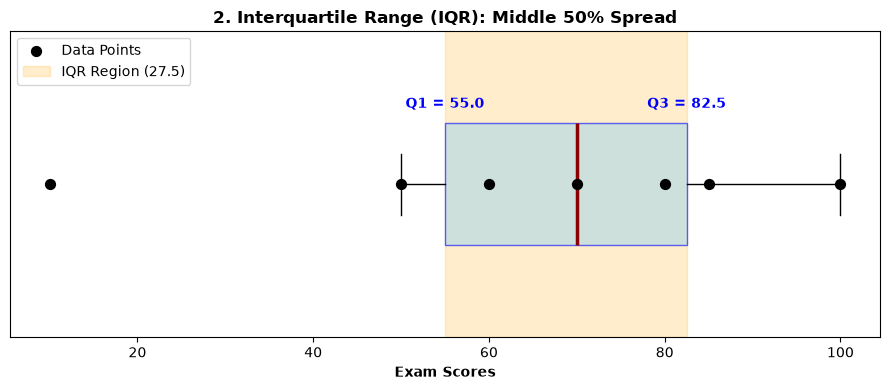

In [4]:
scores = [10, 50, 60, 70, 80, 85, 100]
q1 = np.percentile(scores, 25, method='linear')
q3 = np.percentile(scores, 75, method='linear')
iqr = q3 - q1

fig, ax = plt.subplots(figsize=(9, 4))

# Plot horizontal boxplot
bp = ax.boxplot(scores, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))

# Plot raw points
ax.scatter(scores, [1] * len(scores), color='black', zorder=4, label='Data Points', s=50)

# Highlight IQR span
ax.axvspan(q1, q3, color='orange', alpha=0.2, label=f'IQR Region ({iqr:.1f})')

# Annotate Q1 and Q3
ax.text(q1, 1.25, f'Q1 = {q1:.1f}', ha='center', color='blue', fontweight='bold')
ax.text(q3, 1.25, f'Q3 = {q3:.1f}', ha='center', color='blue', fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Exam Scores', fontweight='bold')
ax.set_title('2. Interquartile Range (IQR): Middle 50% Spread', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 3. Sample Variance (Average square deviation)

In [5]:
plants = [10,20,30]

mean_val = sum(plants) / len(plants)
var_python = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)


var_stats = statistics.variance(plants)

var_np = np.var(plants,ddof=1)

print(f"plain")

plain


# 4. Sample Standard Deviation(spread in original Units)

In [6]:
plants = [10,20,30]

mean_val = sum(plants) / len(plants)

var_val = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)

std_python = math.sqrt(var_val)

std_stats = statistics.stdev(plants)

std_np = np.std(plants, ddof=1)

print(f"Plain Python calculation : {std_python:.1f} cm")
print(f"statistics.stdev() : {std_python:.1f} cm")
print(f"np.std(ddof=1) : {std_python:.1f} cm")

Plain Python calculation : 10.0 cm
statistics.stdev() : 10.0 cm
np.std(ddof=1) : 10.0 cm


In [ ]:
plants = [10,20,30]
mean_val = np.mean(plants)
std_val = np.std(plants,ddof=1)

fig,ax= plt.subplots(figsize=(8,4.5))
x_indices = np.arange(1, len(plants) + 1)
bars = ax.bar(x_indices,plants,width=0.4,color='teal',alpha=0.6,label='Plant Heights(cm)',edgecolor=)